# Massachusetts Roads Dataset

here I will we moddifying the model and seeing the difference in performance.

In [1]:
import torch
from torch import nn
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("balraj98/massachusetts-roads-dataset",force_download=True)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'massachusetts-roads-dataset' dataset.
Path to dataset files: /kaggle/input/massachusetts-roads-dataset


In [3]:
dirc = path
doc_file = pd.read_csv(dirc+"/metadata.csv")
doc_file

,image_id,split,image_souce_url,label_source_url,tiff_image_path,tif_label_path,png_image_path,png_label_path
0,10078660_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078660_15.tiff,tiff/train_labels/10078660_15.tif,png/train/10078660_15.png,png/train_labels/10078660_15.png
1,10078675_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078675_15.tiff,tiff/train_labels/10078675_15.tif,png/train/10078675_15.png,png/train_labels/10078675_15.png
2,10078690_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078690_15.tiff,tiff/train_labels/10078690_15.tif,png/train/10078690_15.png,png/train_labels/10078690_15.png
3,10078705_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078705_15.tiff,tiff/train_labels/10078705_15.tif,png/train/10078705_15.png,png/train_labels/10078705_15.png
4,10078720_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078720_15.tiff,tiff/train_labels/10078720_15.tif,png/train/10078720_15.png,png/train_labels/10078720_15.png
...,...,...,...,...,...,...,...,...
1166,25079170_15,test,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/test/25079170_15.tiff,tiff/test_labels/25079170_15.tif,png/test/25079170_15.png,png/test_labels/25079170_15.png
1167,26278720_15,test,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/test/26278720_15.tiff,tiff/test_labels/26278720_15.tif,png/test/26278720_15.png,png/test_labels/26278720_15.png
1168,26428735_15,test,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/test/26428735_15.tiff,tiff/test_labels/26428735_15.tif,png/test/26428735_15.png,png/test_labels/26428735_15.png
1169,26578720_15,test,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/test/26578720_15.tiff,tiff/test_labels/26578720_15.tif,png/test/26578720_15.png,png/test_labels/26578720_15.png


In [4]:
import os

train_files = doc_file[doc_file["split"] == "train"]["tiff_image_path"]
train_label_files = doc_file[doc_file["split"] == "train"]["tif_label_path"]

train_files = [os.path.join(dirc,f) for f in train_files]
train_label_files = [os.path.join(dirc,f) for f in train_label_files]
train_files = [Image.open(f).resize((256,256)) for f in train_files]
train_label_files = [Image.open(f).resize((256,256)) for f in train_label_files]

In [5]:
from torch.utils.data import DataLoader,Dataset

class RoadDataset(Dataset):
    def __init__(self, inputs, labels, transform, label_transform):
        self.x = [transform(i) for i in inputs]
        self.y = [label_transform(inputs[i],labels[i]) for i in range(len(labels))]

    def __len__(self):
        return len(self.y)

    def __getitem__(self,idx):
        return self.x[idx], self.y[idx]



In [10]:
def input_transform(x:Image.Image,mean,std):
    x = np.asarray(x,dtype=np.float32)/255.0
    x = torch.tensor(x).transpose(-1,-2).transpose(-2,-3)
    return x

def label_transform(x:torch.Tensor, y:Image.Image):
    y = np.asarray(y,dtype=np.float32)/255.0
    y = torch.tensor(y)

    x_ = torch.Tensor(np.asarray(x)).mean(dim=-1)
    x_ = torch.where(x_ == 255, 0, 1)
    #y = torch.where(y > 0.5, 1, 0)
    return y*x_


In [11]:
x = np.asarray([np.asarray(i,dtype=np.float32)/255.0 for i  in train_files])
mean = np.mean(x)
std = np.std(x)
in_transform = lambda x : input_transform(x,mean,std)
train_dataset = RoadDataset(train_files,train_label_files,in_transform,label_transform)
train_size = len(train_dataset)

In [12]:
valid_files = doc_file[doc_file["split"] == "val"]["tiff_image_path"]
valid_label_files = doc_file[doc_file["split"] == "val"]["tif_label_path"]

valid_files = [Image.open(os.path.join(dirc,f)).resize((256,256)) for f in valid_files]
valid_label_files = [Image.open(os.path.join(dirc,f)).resize((256,256)) for f in valid_label_files]

valid_dataset = RoadDataset(valid_files,valid_label_files,in_transform,label_transform)
valid_size = len(valid_dataset)

In [13]:
test_files = doc_file[doc_file["split"] == "test"]["tiff_image_path"]
test_label_files = doc_file[doc_file["split"] == "test"]["tif_label_path"]

test_files = [Image.open(os.path.join(dirc,f)).resize((256,256)) for f in test_files]
test_label_files = [Image.open(os.path.join(dirc,f)).resize((256,256)) for f in test_label_files]

test_dataset = RoadDataset(test_files,test_label_files,in_transform,label_transform)
test_size = len(test_dataset)

# Making more U-net like model

To make it more similar to the original unet-architecture:

i) in order to deal with convolution, I will use the padding such that the size will remain same

ii) this make it reductant to have average pool and max pool at the output giving it more data.

iii) in this there will two convolution layer making it under stand more features

iv) in this the kernal size will be 3x3 rather 5x5

v) in this the hidden layers are increased

In [14]:
class DoubleConv(nn.Module):
  def __init__(self,x,y,z):
    super().__init__()
    self.model = nn.Sequential(
        nn.Conv2d(x,y,3,padding = "same"),
        nn.BatchNorm2d(y),
        nn.Conv2d(y,z,3,padding = "same"),
    )

  def forward(self, x):
    return self.model(x)



class RoadPredictor(nn.Module):
    def __init__(self,device):
        super().__init__()
        self.convs = nn.ModuleList([DoubleConv(3,4,4).to(device),
                                    DoubleConv(4,4,4).to(device),
                                    DoubleConv(4,4,4).to(device),
                                    DoubleConv(8,4,4).to(device),
                                    DoubleConv(8,4,1).to(device),
                                    ])
        self.maxpool = nn.ModuleList([nn.MaxPool2d(2).to(device) for i in range(2)])
        self.upconvs = nn.ModuleList([nn.ConvTranspose2d(4,4,2,stride=2).to(device) for i in range(2)])

    def forward(self,x):
        x1 = self.convs[0](x)
        x2 = self.maxpool[0](x1)
        x3 = self.convs[1](x2)
        x4 = self.maxpool[1](x3)
        x5 = self.convs[2](x4)
        x6 = self.upconvs[0](x5)
        x6 = torch.concat([x6,x3], dim=1)
        x7 = self.convs[3](x6)
        x8 = self.upconvs[1](x7)
        x8 = torch.concat([x8,x1], dim=1)
        x8 = self.convs[4](x8)
        return x8.reshape(-1,256*256)

In [15]:
class DiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred = pred.reshape(-1)
        target = target.reshape(-1)
        intersection = torch.dot(pred,target)
        dice = (2.*intersection)/(pred.sum() + target.sum())
        return 1 - dice

class BCEAndDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss1 = nn.BCEWithLogitsLoss()
        self.loss2 = DiceLoss()

    def forward(self, pred, target):
        return .005*self.loss1(pred,target) + self.loss2(pred,target)

class DoubleDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss1 = DiceLoss()
        self.loss2 = DiceLoss()
    def forward(self, pred, target):
        return self.loss1(pred,target) + 1e-3*self.loss2(1 - pred,1 - target)

class FocalLoss(nn.Module):
    def __init__(self, weight=1., gamma = 2.):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred = pred.reshape(-1)
        target = target.reshape(-1)
        l = (1 - self.weight)*target*((1 - pred)**self.gamma)*torch.log(pred) + self.weight*(1 - target)*(pred**self.gamma)*torch.log(1 - pred)
        return -l.sum()

In [16]:

def train_model(model,loss_fn,opt,max_epochs,train_data,valid_data,device):
    model = model.to(device)
    loss_fn = loss_fn.to(device)
    accuracy = []
    losses = []
    model.train()
    for i in range(max_epochs):
        s = 0
        for (x,y) in train_data:
            y = y.to(device).reshape(-1,256*256)
            x = x.to(device)
            pred = model(x)
            loss = loss_fn(pred,y)
            losses.append(loss.cpu().item())
            loss.backward()
            s+=loss.item()
            opt.step()
            opt.zero_grad()
        with torch.no_grad():
            total = 0
            for (x,y) in valid_data:
                y = y.to(device).reshape(-1,256*256)
                x = x.to(device)
                pred = model(x)
                pred = torch.sigmoid(pred)
                pred = torch.where(pred >= 0.5, 1, 0)
                total += (y == pred).reshape(-1).sum().cpu().item()
            accuracy.append(total/valid_size/256/256)
            if (i%10 == 0):
                print(f"Epoch {i+1}: valid acc :{accuracy[-1]} training_loss:{losses[-1]}")

    return model, accuracy , losses

In [17]:
def diceloss(target, pred):
    pred = torch.sigmoid(pred)
    pred = pred.reshape(-1)
    target = target.reshape(-1)
    intersection = torch.dot(pred,target)
    score = (2.*intersection)/(pred.sum() + target.sum())
    return score

def iou(target, pred):
    pred = torch.sigmoid(pred)
    pred = pred.reshape(-1)
    target = target.reshape(-1)
    intersection = torch.dot(pred,target)
    score = intersection/(pred.sum() + target.sum()-intersection)
    return score

def eval_model(model,test_data):
  model.eval()
  tp= tn = fp = fn = 0
  dice_loss = 0
  iou_loss = 0
  for (x,y) in test_data:
    x = x.to(device)
    y = y.to(device).reshape(-1,256*256)
    pred = model(x)
    y_ = torch.where(y >0.5, 1, 0)
    pred_ = torch.where(pred > 0.5, 1, 0)
    matches = (y_ == pred_)
    tp += (matches*(y_==1)).sum()
    tn += (matches*(y_==0)).sum()
    fp += ((~matches)*(y_==1)).sum()
    fn += ((~matches)*(y_==0)).sum()
    dice_loss += diceloss(y,pred)
    iou_loss += iou(y,pred)
  print(f"""
  Accuracy: {(tp+tn)/(tp+tn+fp+fn)}
  Recall: {(tp)/(tp+fn)}
  Presicion: {(tp)/(tp+fp)}
  IOU: {iou_loss}
  diceloss: {dice_loss}
  """)


In [18]:
train_data = DataLoader(train_dataset,batch_size=512)
valid_data = DataLoader(valid_dataset,batch_size=4096)
test_data = DataLoader(test_dataset,batch_size=4096)

In [19]:
import gc

gc.collect()

torch.cuda.empty_cache()

Epoch 1: valid acc :0.5359606061662946 training_loss:0.9553611278533936
Epoch 11: valid acc :0.49607631138392855 training_loss:0.9254017472267151
Epoch 21: valid acc :0.5367954799107143 training_loss:0.9191612005233765
Epoch 31: valid acc :0.5670525687081474 training_loss:0.9107282161712646
Epoch 41: valid acc :0.5810677664620536 training_loss:0.9043845534324646
Epoch 51: valid acc :0.5991276332310268 training_loss:0.8973110318183899
Epoch 61: valid acc :0.6308920724051339 training_loss:0.8905848264694214
Epoch 71: valid acc :0.6889168875558036 training_loss:0.891802966594696
Epoch 81: valid acc :0.7130443028041294 training_loss:0.8686028718948364
Epoch 91: valid acc :0.7525209699358258 training_loss:0.836593747138977
Epoch 101: valid acc :0.77728271484375 training_loss:0.8062102198600769
Epoch 111: valid acc :0.7867682320731026 training_loss:0.7827221155166626
Epoch 121: valid acc :0.7942657470703125 training_loss:0.7590949535369873
Epoch 131: valid acc :0.7977403913225446 training_lo

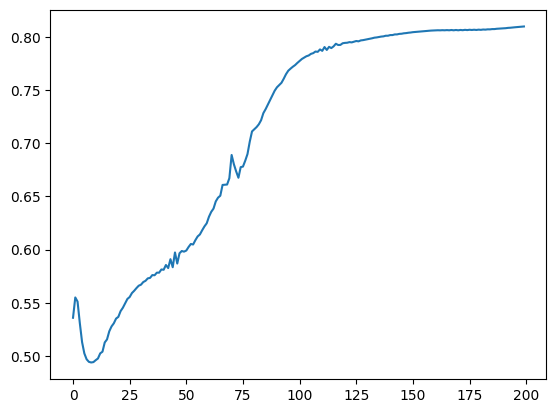

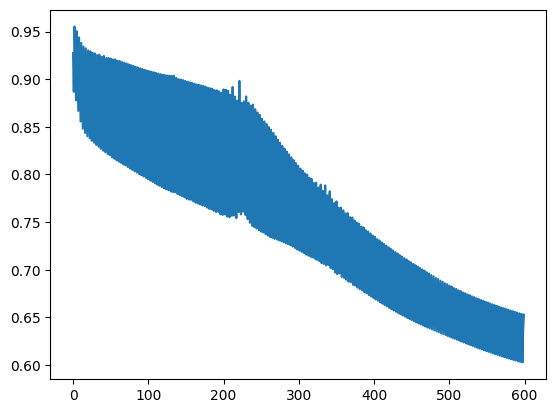

In [20]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
model = RoadPredictor(device)
loss_fn = DiceLoss()
opt = torch.optim.AdamW(model.parameters(),lr = 1e-3)
model_diceloss,accuracy,losses = train_model(model,loss_fn,opt,200,train_data,valid_data,device)

plt.plot(accuracy)
plt.show()
plt.plot(losses)


  Accuracy: 0.9435860514640808
  Recall: 0.4282391667366028
  Presicion: 0.4236338436603546
  IOU: 0.244042307138443
  diceloss: 0.3923376500606537
  


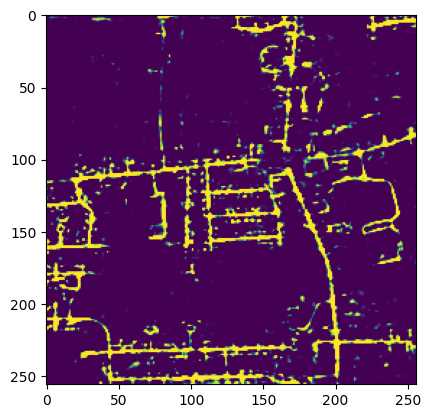

In [21]:
with torch.no_grad():
    total = 0
    for (x,y) in valid_data:
        y = y.to(device).reshape((-1,256*256))
        x = x.to(device)
        pred = model_diceloss(x)
        pred = torch.sigmoid(pred)
        break
pred2 = (pred[0])
plt.imshow(pred2.reshape(256,256).cpu())
eval_model(model_diceloss,test_data)

Epoch 1: valid acc :0.5531365530831474 training_loss:20439.40234375
Epoch 11: valid acc :0.47027478899274555 training_loss:7444.00048828125
Epoch 21: valid acc :0.46369171142578125 training_loss:6624.02685546875
Epoch 31: valid acc :0.4377561296735491 training_loss:6621.16845703125
Epoch 41: valid acc :0.41968209402901785 training_loss:6694.4326171875
Epoch 51: valid acc :0.41253662109375 training_loss:6687.71923828125
Epoch 61: valid acc :0.41049630301339285 training_loss:6496.10546875
Epoch 71: valid acc :0.40782601492745535 training_loss:6346.9814453125
Epoch 81: valid acc :0.4027012416294643 training_loss:6295.4951171875
Epoch 91: valid acc :0.39691380092075895 training_loss:6262.09765625
Epoch 101: valid acc :0.39075796944754465 training_loss:6235.271484375
Epoch 111: valid acc :0.38381849016462055 training_loss:6213.3193359375
Epoch 121: valid acc :0.37603977748325895 training_loss:6194.3720703125
Epoch 131: valid acc :0.36766488211495535 training_loss:6184.318359375
Epoch 141: v

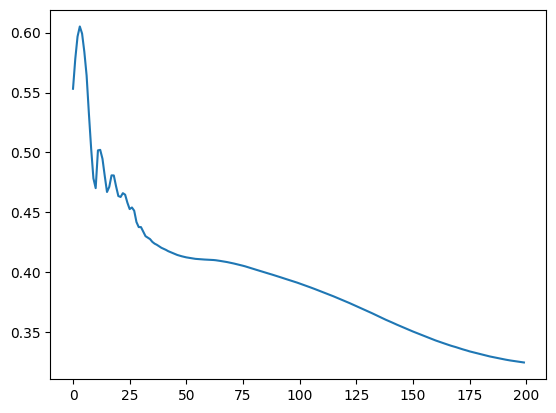

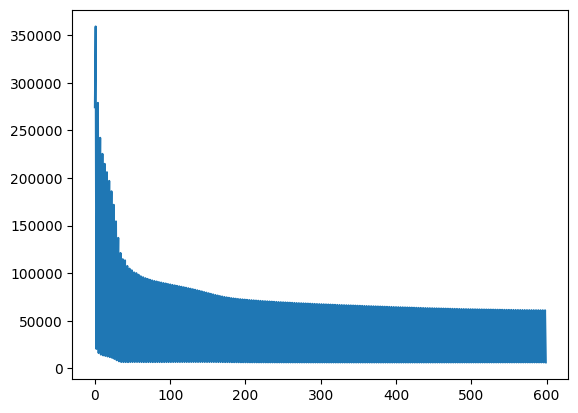

In [23]:
model = RoadPredictor(device)
loss_fn = FocalLoss(5e-3,3)
opt = torch.optim.AdamW(model.parameters(),lr = 1e-3)
model_focalloss,accuracy,losses = train_model(model,loss_fn,opt,200,train_data,valid_data,device)

plt.plot(accuracy)
plt.show()
plt.plot(losses)


  Accuracy: 0.7687166333198547
  Recall: 0.1562359780073166
  Presicion: 0.8366711139678955
  IOU: 0.058821313083171844
  diceloss: 0.11110715568065643
  


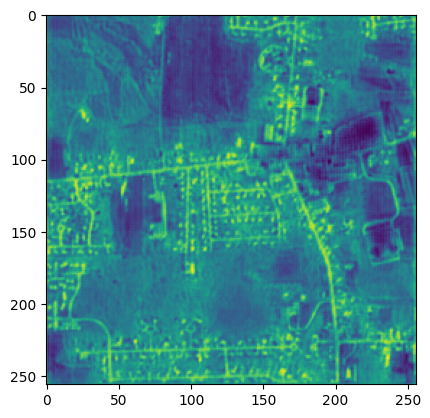

In [24]:
with torch.no_grad():
    total = 0
    for (x,y) in valid_data:
        y = y.to(device).reshape((-1,256*256))
        x = x.to(device)
        pred = model_focalloss(x)
        pred = torch.sigmoid(pred)
        break
pred2 = pred[0]
plt.imshow(pred2.reshape(256,256).cpu())
eval_model(model_focalloss,test_data)

Epoch 1: valid acc :0.3723199026925223 training_loss:0.7777237892150879
Epoch 11: valid acc :0.39943150111607145 training_loss:0.7010957598686218
Epoch 21: valid acc :0.6198098318917411 training_loss:0.652571439743042
Epoch 31: valid acc :0.7268622262137276 training_loss:0.5625489950180054
Epoch 41: valid acc :0.8024215698242188 training_loss:0.4356652796268463
Epoch 51: valid acc :0.8400148664202008 training_loss:0.31099334359169006
Epoch 61: valid acc :0.8488878522600446 training_loss:0.22013689577579498
Epoch 71: valid acc :0.8499832153320312 training_loss:0.16487523913383484
Epoch 81: valid acc :0.8491919381277901 training_loss:0.13309723138809204
Epoch 91: valid acc :0.8467167445591518 training_loss:0.11410097777843475
Epoch 101: valid acc :0.8438088553292411 training_loss:0.10189004242420197
Epoch 111: valid acc :0.8421598161969867 training_loss:0.09372491389513016
Epoch 121: valid acc :0.8409358433314732 training_loss:0.08807332068681717
Epoch 131: valid acc :0.8389707292829242 

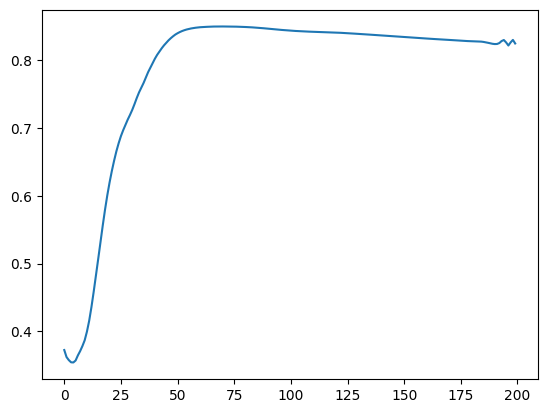

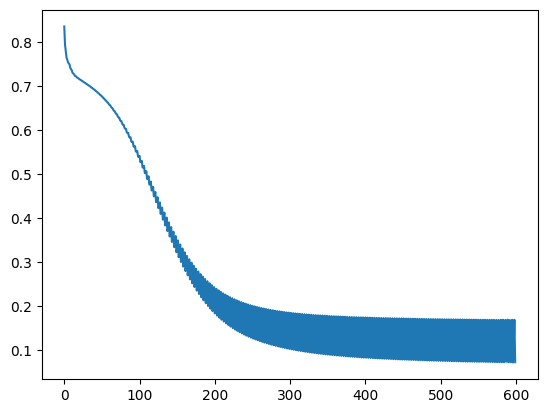

In [25]:
model = RoadPredictor(device)
loss_fn = nn.BCEWithLogitsLoss()
opt = torch.optim.Adam(model.parameters(),lr = 1e-3)
model_bce,accuracy,losses = train_model(model,loss_fn,opt,200,train_data,valid_data,device)

plt.plot(accuracy)
plt.show()
plt.plot(losses)
plt.show()


  Accuracy: 0.9527304768562317
  Recall: 0.5891396403312683
  Presicion: 0.14252664148807526
  IOU: 0.1469043791294098
  diceloss: 0.2561754882335663
  


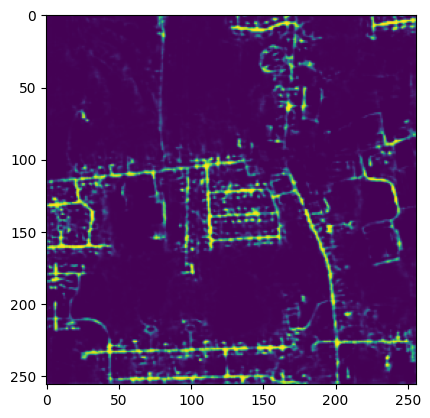

In [26]:
with torch.no_grad():
    total = 0
    for (x,y) in valid_data:
        y = y.to(device).reshape((-1,256*256))
        x = x.to(device)
        pred = model_bce(x)
        pred = torch.sigmoid(pred)
        break
pred2 = pred[0]
plt.imshow(pred2.reshape(256,256).cpu())
eval_model(model_bce,test_data)

Epoch 1: valid acc :0.40525054931640625 training_loss:0.9602177739143372
Epoch 11: valid acc :0.5088108607700893 training_loss:0.9283716678619385
Epoch 21: valid acc :0.561720711844308 training_loss:0.9188674688339233
Epoch 31: valid acc :0.6032366071428571 training_loss:0.914280891418457
Epoch 41: valid acc :0.6667262486049107 training_loss:0.8851395845413208
Epoch 51: valid acc :0.7355085100446429 training_loss:0.8291544318199158
Epoch 61: valid acc :0.7565907069614956 training_loss:0.7818991541862488
Epoch 71: valid acc :0.7746298653738839 training_loss:0.7443546056747437
Epoch 81: valid acc :0.7855845860072544 training_loss:0.7241268157958984
Epoch 91: valid acc :0.7889502389090401 training_loss:0.7043960690498352
Epoch 101: valid acc :0.7997676304408482 training_loss:0.6821264028549194
Epoch 111: valid acc :0.8027060372488839 training_loss:0.6690086126327515
Epoch 121: valid acc :0.8040586199079242 training_loss:0.6504631042480469
Epoch 131: valid acc :0.8088498796735492 training_

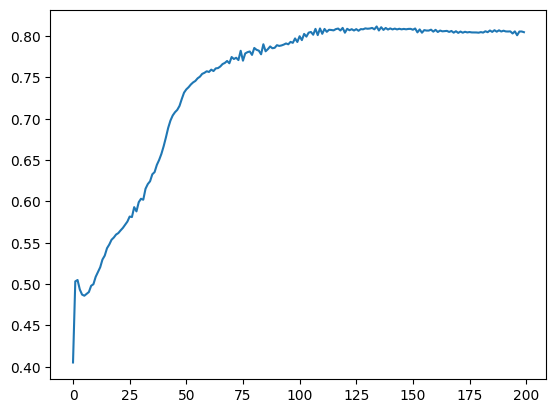

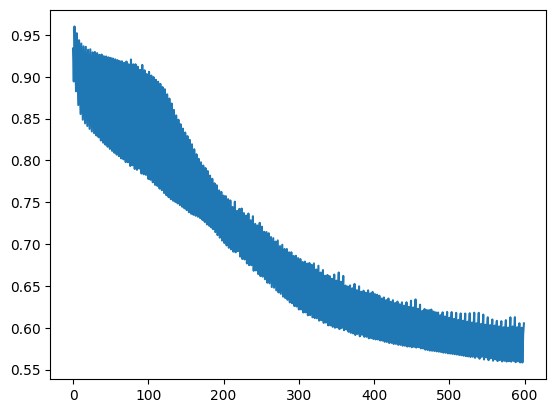

In [27]:
model = RoadPredictor(device)
loss_fn = BCEAndDiceLoss()
opt = torch.optim.Adam(model.parameters(),lr = 2e-3)
model_bceanddiceloss,accuracy,losses = train_model(model,loss_fn,opt,200,train_data,valid_data,device)

plt.plot(accuracy)
plt.show()
plt.plot(losses)


  Accuracy: 0.953035295009613
  Recall: 0.5348240733146667
  Presicion: 0.37858128547668457
  IOU: 0.2612922489643097
  diceloss: 0.41432467103004456
  


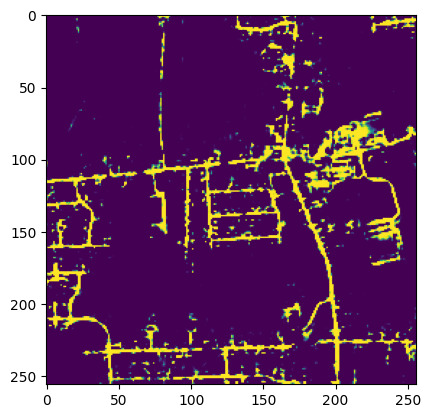

In [28]:
with torch.no_grad():
    total = 0
    for (x,y) in valid_data:
        y = y.to(device).reshape((-1,256*256))
        x = x.to(device)
        pred = model_bceanddiceloss(x)
        pred = torch.sigmoid(pred)
        break
pred2 = pred[0]
plt.imshow(pred2.reshape(256,256).cpu())
eval_model(model_bceanddiceloss, test_data)

Epoch 1: valid acc :0.37845066615513395 training_loss:0.9557938575744629
Epoch 11: valid acc :0.48874337332589285 training_loss:0.9262431263923645
Epoch 21: valid acc :0.5414232526506696 training_loss:0.9131935834884644
Epoch 31: valid acc :0.554671151297433 training_loss:0.9163538813591003
Epoch 41: valid acc :0.6318991524832589 training_loss:0.8929966688156128
Epoch 51: valid acc :0.7110780988420758 training_loss:0.8539891242980957
Epoch 61: valid acc :0.757615225655692 training_loss:0.8095725178718567
Epoch 71: valid acc :0.7728445870535714 training_loss:0.7624992728233337
Epoch 81: valid acc :0.7894199916294643 training_loss:0.7329959869384766
Epoch 91: valid acc :0.7972619192940849 training_loss:0.6954230666160583
Epoch 101: valid acc :0.7957763671875 training_loss:0.6658760905265808
Epoch 111: valid acc :0.8130471365792411 training_loss:0.6629329323768616
Epoch 121: valid acc :0.7980902535574776 training_loss:0.6491511464118958
Epoch 131: valid acc :0.798445565359933 training_los

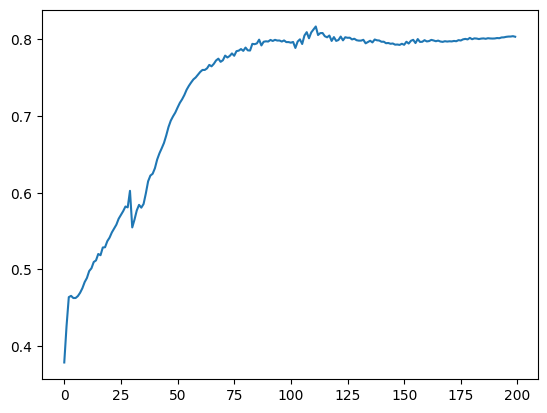

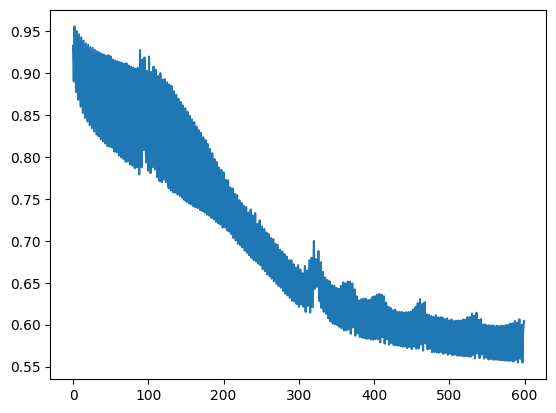

In [31]:
model = RoadPredictor(device)
loss_fn = DoubleDiceLoss()
opt = torch.optim.Adam(model.parameters(),lr = 2e-3)
model_doublediceloss,accuracy,losses = train_model(model,loss_fn,opt,200,train_data,valid_data,device)

plt.plot(accuracy)
plt.show()
plt.plot(losses)


  Accuracy: 0.947468638420105
  Recall: 0.4683699607849121
  Presicion: 0.4692852199077606
  IOU: 0.2776605784893036
  diceloss: 0.434639036655426
  


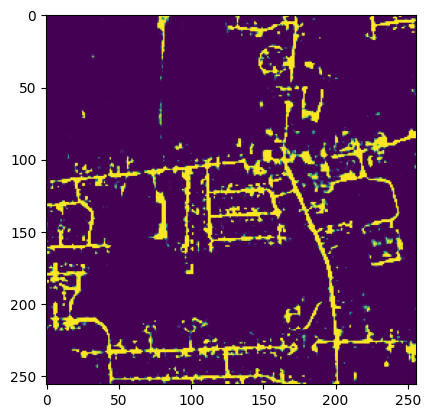

In [32]:
with torch.no_grad():
    total = 0
    for (x,y) in valid_data:
        y = y.to(device).reshape((-1,256*256))
        x = x.to(device)
        pred = model_doublediceloss(x)
        pred = torch.sigmoid(pred)
        break
pred2 = pred[0]
plt.imshow(pred2.reshape(256,256).cpu())
eval_model(model_doublediceloss, test_data)

In [33]:
torch.save(model_focalloss.state_dict(), f"./model_focal.trhmodel")
torch.save(model_doublediceloss.state_dict(), f"./model_doublediceloss.trhmodel")
torch.save(model_bceanddiceloss.state_dict(), f"./model_bceanddiceloss.trhmodel")
torch.save(model_bce.state_dict(), f"./model_bce.trhmodel")
torch.save(model_diceloss.state_dict(), f"./model_diceloss.trhmodel")